Final SNN Implementation (Paper-Reproduced)

In [11]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import BertTokenizer, TFBertModel
import arff
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [12]:
# ==========================
# Step 1: Load data
# ===========================


train_df=pd.read_csv("target_train.csv") #relative file paths

test_df=pd.read_csv("target_test.csv") #relative file paths

# sample_matching_df = pairwise_df[pairwise_df['label'] == 1].sample(n=50000, random_state=42)
# sample_nonmatching_df = pairwise_df[pairwise_df['label'] == 0].sample(n=50000, random_state=42)
# sample_df = pd.concat([sample_matching_df, sample_nonmatching_df]).reset_index(drop=True)

# # Optionally, print sample_df to inspect
print("Train record pairs:")
print(train_df[['uid1', 'uid2', 'label']].head())
print("Test record pairs:")
print(test_df[['uid1', 'uid2', 'label']].head())

Train record pairs:
        uid1       uid2  label
0  6488772-1  7383003-1      0
1  6069825-1  6069825-2      1
2  2740309-1  8225499-1      0
3  1283745-1  7093274-2      0
4  6062634-1  8245233-2      0
Test record pairs:
        uid1       uid2  label
0  6159344-1  8454461-1      0
1  4743268-1  4743268-2      1
2  8442437-3  8442437-4      1
3  8625395-1  8625395-4      1
4  2687548-2  2687548-9      1


In [ ]:
# Step 3: Generate embeddings only for train and test separately
import numpy as np
from transformers import BertTokenizer, TFBertModel
import tensorflow as tf
from tqdm import tqdm

# Load pretrained BERT model and tokenizer
from transformers import BertTokenizer, TFBertModel

# Load ClinicalBERT
tokenizer = BertTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
bert_model = TFBertModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")


# Helper function for batched embedding generation

def generate_embeddings_batched(texts, batch_size=32, max_length=512):
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts.iloc[i:i+batch_size].tolist()
        inputs = tokenizer(
            batch,
            return_tensors="tf",
            padding=True,
            truncation=True,
            max_length=max_length  # Truncate to 512 tokens
        )
        outputs = bert_model(inputs["input_ids"])
        cls_embeddings = outputs.last_hidden_state[:, 0, :]  # [CLS] token
        all_embeddings.append(cls_embeddings.numpy())

    return np.vstack(all_embeddings)
# Encode and save embeddings
x1_train = generate_embeddings_batched(train_df['text1'])
x2_train = generate_embeddings_batched(train_df['text2'])
y_train = train_df['label'].values.astype(np.float32)

x1_test = generate_embeddings_batched(test_df['text1'])
x2_test = generate_embeddings_batched(test_df['text2'])
y_test = test_df['label'].values.astype(np.float32)



c:\ProgramData\anaconda3\envs\snn_env\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some layers from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT were not used when initializing TFBertModel: ['nsp___cls', 'mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertModel were initialized from the model checkpoint at emilyalsentzer/Bio_Clin

KeyboardInterrupt: 

In [3]:
# Directory to store cached files
# os.makedirs("clinicalbert", exist_ok=True)
# # save the embeddings for later use
# np.save("clinicalbert/x1_train.npy", x1_train)
# np.save("clinicalbert/x2_train.npy", x2_train)
# np.save("clinicalbert/y_train.npy", y_train)
# np.save("clinicalbert/x1_test.npy", x1_test)
# np.save("clinicalbert/x2_test.npy", x1_test)
# np.save("clinicalbert/y_test.npy", y_test)

# # For the later experiments load the embeddings using following code
# x1_train = np.load("clinicalbert/x1_train.npy")
# x2_train = np.load("clinicalbert/x2_train.npy")
# y_train = np.load("clinicalbert/y_train.npy")
# x1_test = np.load("clinicalbert/x1_test.npy")
# x2_test = np.load("clinicalbert/x2_test.npy")
# y_test = np.load("clinicalbert/y_test.npy")



# # === Load precomputed BERT embeddings ===
    #np.load loads in a .npy file, file path to file located in brackets.
x1_train = np.load("BaseSplit/x1_shadow_test.npy") 
x2_train = np.load("BaseSplit/x2_target_test.npy")
y_train = np.load("BaseSplit/y_shadow_train.npy")
x1_test = np.load("BaseSplit/x1_shadow_test.npy")
x2_test = np.load("BaseSplit/x2_target_test.npy")
y_test = np.load("BaseSplit/y_shadow_test.npy")
print("Mean diff between x1 and x2:", np.mean(np.abs(x1_test - x2_test))) #computes absolute difference between the two embedding sets.
assert not np.allclose(x1_test, x2_test), "x1 and x2 appear to be identical!" #stops execution if embeddings are too similar.

Mean diff between x1 and x2: 0.27226368


In [4]:
# ====================================
# Step 3: Build Siamese Autoencoder
# ====================================
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
def build_siamese_autoencoder(embedding_dim):
    encoder_input = Input(shape=(embedding_dim,)) #encoders input layer.
    x = layers.Dense(50, activity_regularizer=regularizers.l1(0.01))(encoder_input) #adds a dense layer with L1 regulars ()
    x = layers.LeakyReLU(alpha=0.01)(x) #LeakyReLu avoids dead neurons ()
    encoder_output = layers.Dense(embedding_dim, activation='relu')(x) #outputs embeddings of the same size/dimensions
    encoder = Model(encoder_input, encoder_output) #builds encoder model using input and output.

    decoder_input = Input(shape=(embedding_dim,)) #decoder input layer
    decoder_output = layers.Dense(embedding_dim, activation='sigmoid')(decoder_input) #decoder reconstructs original embedding.
        #sigmoid makes output a probability.

    decoder = Model(decoder_input, decoder_output) #builds decoder  

    input1 = Input(shape=(embedding_dim,))
    input2 = Input(shape=(embedding_dim,))
    encoded1 = encoder(input1)
    encoded2 = encoder(input2)
    recon1 = decoder(encoded1)
    recon2 = decoder(encoded2)

    merged_output = layers.Concatenate()([recon1, recon2]) #concats both reconstructions through one output vector.
    model = Model(inputs=[input1, input2], outputs=merged_output) #this builds the full Siamese autoencoder model.
    return model, encoder #returns full model as well as the encoder.

def hybrid_classification_loss(margin=2.5, alpha=1.0): #function for custom loss
    def loss_fn(y_true, y_pred): #inner function that computes the actual loss
        emb_dim = tf.shape(y_pred)[1] // 2 #tensorflow shape splits the concat output into two halves, recon 1 and recon 2.
        recon1 = y_pred[:, :emb_dim] #recon 1 variable
        recon2 = y_pred[:, emb_dim:] #recon 2 variable
        recon_loss = tf.reduce_mean(tf.square(recon1 - recon2), axis=1) #measures reconstruction diff between two halves.
            #tensorflow reduce mean , computes the mean of elements across tensorflow.
            #tensorflow square , squares the differernce between two halves.

        distances = tf.sqrt(tf.reduce_sum(tf.square(recon1 - recon2), axis=1)) #completes euclidean distancec between reconstructions
            #tensorflow sqrt, square roots the input.
        y_true = tf.cast(y_true, tf.float32) #makes labels floats for math operations, cast makes a new format (floats in this case).
        contrastive_loss = y_true * tf.square(distances) + (1 - y_true) * tf.square(tf.maximum(margin - distances, 0))
        return tf.reduce_mean(alpha * recon_loss + contrastive_loss)
    return loss_fn
embedding_dim = x1_train.shape[1] #gets embedding size from data.
sa_model, encoder = build_siamese_autoencoder(embedding_dim) #builds SAE and retrieves the encoder.
sa_model.compile(optimizer='adam', loss=hybrid_classification_loss(margin=2.5, alpha=1.0)) #compiles using ADAM and custom hybrid loss.
sa_model.fit([x1_train, x2_train], y_train, epochs=30, batch_size=256, validation_split=0.1) #trains SAE on paired embeddings
    #epochs 30 tells SAE to run 30 full passes over training data. if increased it trains longer.

Epoch 1/30
29/29 [==============================] - 1s 12ms/step - loss: 2.0555 - val_loss: 1.8576
Epoch 2/30
29/29 [==============================] - 0s 9ms/step - loss: 1.8070 - val_loss: 1.8004
Epoch 3/30
29/29 [==============================] - 0s 8ms/step - loss: 1.7727 - val_loss: 1.7545
Epoch 4/30
29/29 [==============================] - 0s 8ms/step - loss: 1.7400 - val_loss: 1.7622
Epoch 5/30
29/29 [==============================] - 0s 8ms/step - loss: 1.7336 - val_loss: 1.7603
Epoch 6/30
29/29 [==============================] - 0s 8ms/step - loss: 1.7418 - val_loss: 1.7541
Epoch 7/30
29/29 [==============================] - 0s 9ms/step - loss: 1.7145 - val_loss: 1.7150
Epoch 8/30
29/29 [==============================] - 0s 9ms/step - loss: 1.7167 - val_loss: 1.8279
Epoch 9/30
29/29 [==============================] - 0s 9ms/step - loss: 1.7273 - val_loss: 1.7350
Epoch 10/30
29/29 [==============================] - 0s 9ms/step - loss: 1.7183 - val_loss: 1.8335
Epoch 11/30
29/29 

In [5]:
# ==========================================================
# Evaluate the Siamese Autoencoder (Threshold-based)
# ==========================================================

# Get reconstructions
encoded1_train = encoder.predict(x1_train)
encoded2_train = encoder.predict(x2_train)
encoded1_test = encoder.predict(x1_test)
encoded2_test = encoder.predict(x2_test)

# Compute Euclidean distances
train_distances = np.sqrt(np.sum((encoded1_train - encoded2_train)**2, axis=1))
test_distances = np.sqrt(np.sum((encoded1_test - encoded2_test)**2, axis=1))

# Use fixed threshold (e.g., 1.0) to classify matches
threshold = 1.0
train_pred = (train_distances < threshold).astype(int)
test_pred = (test_distances < threshold).astype(int)

# Accuracy & F1 #changed from y_train to y_test as embeddings given did not have a y_train with enough values.
train_acc = accuracy_score(y_test, train_pred)
train_f1 = f1_score(y_test, train_pred)
test_acc = accuracy_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred)

print("------ Siamese Autoencoder Evaluation ------")
print(f"Training Accuracy: {train_acc:.4f}, F1 Score: {train_f1:.4f}")
print(f"Test Accuracy: {test_acc:.4f}, F1 Score: {test_f1:.4f}")


250/250 [==============================] - 0s 396us/step
------ Siamese Autoencoder Evaluation ------
Training Accuracy: 0.5065, F1 Score: 0.3020
Test Accuracy: 0.5065, F1 Score: 0.3020


In [6]:
# ====================================
# Step 4: Add Classification Head
# ====================================
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate

# Step 1: Get encoded outputs
encoded1_train = encoder.predict(x1_train)
encoded2_train = encoder.predict(x2_train)
encoded1_test = encoder.predict(x1_test)
encoded2_test = encoder.predict(x2_test)

# Step 2: Compute absolute differences (Siamese-style)
diff_train = np.abs(encoded1_train - encoded2_train)
diff_test = np.abs(encoded1_test - encoded2_test)

# Step 3: Build classification model
input_diff = Input(shape=(diff_train.shape[1],))
x = Dense(64, activation='relu')(input_diff)
x = Dense(32, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)
clf_model = Model(inputs=input_diff, outputs=output)

clf_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 4: Train the classifier
clf_model.fit(diff_train, y_train, epochs=20, batch_size=256, validation_split=0.1)

# Step 5: Evaluate
y_pred_prob = clf_model.predict(diff_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

from sklearn.metrics import accuracy_score, f1_score, classification_report

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nClassifier Evaluation:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nDetailed report:\n", classification_report(y_test, y_pred))


250/250 [==============================] - 0s 400us/step
Epoch 1/20
29/29 [==============================] - 0s 3ms/step - loss: 0.6934 - accuracy: 0.4994 - val_loss: 0.6931 - val_accuracy: 0.5038
Epoch 2/20
29/29 [==============================] - 0s 1ms/step - loss: 0.6939 - accuracy: 0.4989 - val_loss: 0.6932 - val_accuracy: 0.5063
Epoch 3/20
29/29 [==============================] - 0s 1ms/step - loss: 0.6921 - accuracy: 0.5264 - val_loss: 0.6938 - val_accuracy: 0.4988
Epoch 4/20
29/29 [==============================] - 0s 1ms/step - loss: 0.6907 - accuracy: 0.5390 - val_loss: 0.6929 - val_accuracy: 0.5275
Epoch 5/20
29/29 [==============================] - 0s 1ms/step - loss: 0.6889 - accuracy: 0.5449 - val_loss: 0.6943 - val_accuracy: 0.5000
Epoch 6/20
29/29 [==============================] - 0s 1ms/step - loss: 0.6871 - accuracy: 0.5508 - val_loss: 0.6939 - val_accuracy: 0.5063
Epoch 7/20
29/29 [==============================] - 0s 1ms/step - loss: 0.6855 - accuracy: 0.5565 - val

250/250 [==============================] - 0s 416us/step
Classifier Accuracy: 0.492
Classifier F1 Score: 0.414915059026778
Classification Report:
               precision    recall  f1-score   support

         0.0       0.49      0.62      0.55      3992
         1.0       0.49      0.36      0.41      4008

    accuracy                           0.49      8000
   macro avg       0.49      0.49      0.48      8000
weighted avg       0.49      0.49      0.48      8000



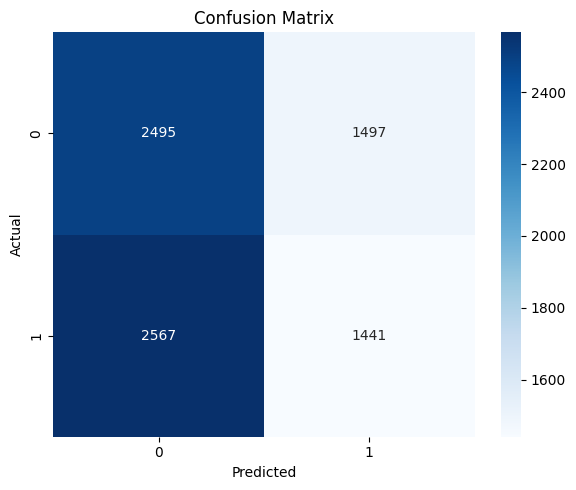

In [7]:
# ====================================
# Step 5: Evaluation and Visualization
# ====================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

y_pred_prob = clf_model.predict(diff_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Classifier Accuracy:", acc)
print("Classifier F1 Score:", f1)
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

# Save Model
clf_model.save("snn_classifier_model.h5")

In [8]:
print("Train label distribution:")
print(pd.Series(y_train).value_counts())


Train label distribution:
1.0    16031
0.0    15969
Name: count, dtype: int64


In [9]:
# =========================================
# learn threshold from validation set
# ========================================

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras import regularizers
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, f1_score, classification_report
import numpy as np
# -------------------------------------------------------
# Step 1: Create pseudo-validation set from training data
# -------------------------------------------------------
diff_train_full = np.abs(x1_train - x2_train)
diff_test = np.abs(x1_test - x2_test)

# Split 80% train / 20% val for threshold tuning
diff_train_final, diff_val, y_train_final, y_val = train_test_split(
    diff_train_full, y_test, test_size=0.2, random_state=42, stratify=y_test
)

# -------------------------------------------------------
# Step 2: Build and Train MLP Classifier
# -------------------------------------------------------
input_diff = Input(shape=(diff_train_final.shape[1],))
x = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01))(input_diff)
x = Dropout(0.5)(x)
x = Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
output = Dense(1, activation='sigmoid')(x)
clf_model = Model(inputs=input_diff, outputs=output)

clf_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
clf_model.fit(diff_train_final, y_train_final, epochs=30, batch_size=256, validation_split=0.1)

# -------------------------------------------------------
# Step 3: Tune threshold on the validation set
# -------------------------------------------------------
y_val_prob = clf_model.predict(diff_val).flatten()

best_threshold = 0.5
best_f1 = 0

for threshold in np.arange(0.1, 0.9, 0.01):
    y_pred_val = (y_val_prob >= threshold).astype(int)
    _, _, f1, _ = precision_recall_fscore_support(y_val, y_pred_val, average='binary')
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"\n Best Threshold (on pseudo-val set): {best_threshold:.2f} — Best F1 Score: {best_f1:.4f}")

# -------------------------------------------------------
# Step 4: Evaluate on the true test set using tuned threshold
# -------------------------------------------------------
y_test_prob = clf_model.predict(diff_test).flatten()
y_test_pred = (y_test_prob >= best_threshold).astype(int)

acc = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("\n Final Evaluation on Test Set:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nDetailed Report:\n", classification_report(y_test, y_test_pred))

# Save predictions
import pandas as pd
pd.DataFrame({
    "True Label": y_test,
    "Predicted Label": y_test_pred,
    "Confidence": y_test_prob
}).to_csv("final_test_predictions.csv", index=False)
print(" Test predictions saved to 'final_test_predictions.csv'")


Epoch 1/30
23/23 [==============================] - 0s 4ms/step - loss: 2.0763 - accuracy: 0.5247 - val_loss: 1.7713 - val_accuracy: 0.5297
Epoch 2/30
23/23 [==============================] - 0s 2ms/step - loss: 1.5624 - accuracy: 0.5700 - val_loss: 1.3696 - val_accuracy: 0.5406
Epoch 3/30
23/23 [==============================] - 0s 2ms/step - loss: 1.2385 - accuracy: 0.5837 - val_loss: 1.1258 - val_accuracy: 0.5594
Epoch 4/30
23/23 [==============================] - 0s 2ms/step - loss: 1.0431 - accuracy: 0.6016 - val_loss: 0.9864 - val_accuracy: 0.5859
Epoch 5/30
23/23 [==============================] - 0s 2ms/step - loss: 0.9298 - accuracy: 0.6014 - val_loss: 0.8905 - val_accuracy: 0.5813
Epoch 6/30
23/23 [==============================] - 0s 2ms/step - loss: 0.8532 - accuracy: 0.6127 - val_loss: 0.8344 - val_accuracy: 0.6141
Epoch 7/30
23/23 [==============================] - 0s 2ms/step - loss: 0.8033 - accuracy: 0.6104 - val_loss: 0.7940 - val_accuracy: 0.5641
Epoch 8/30
23/23 [==

c:\ProgramData\anaconda3\envs\snn_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\envs\snn_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\envs\snn_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramDat

In [ ]:
# ----------------------------
# TRAINING K-SHADOW MODELS
# -----------------------------

In [10]:
# ----------------------------
# Classifier Head for K Shadow Models
# ---------------------------

k = 5 #5 is the number of shadow models I wanted to train.
shadow_predictions = [] #shadow predictions array to store info
shadow_labels = [] #shadow labels array to store info

for i in range(k):
    print(f"\n Training Shadow Model {i+1}") #for loop that prints what Shadow Training model it is up too for the output.

    # Picks 8000 random rows
    rows = np.random.randint(0, len(y_test), 8000) 
    x1_shad = x1_train[rows] #random 8000 rows in the shadow training datasets
    x2_shad = x2_train[rows] #same as above
    y_shad = y_test[rows] #same as above

    # Use same encoder to encode shadow models.
    encoded1_shad = encoder.predict(x1_shad) #passes raw shadow inputs through trained SAE encoder.
    encoded2_shad = encoder.predict(x2_shad) #same as above but for different dataset.


    # Compute absolute differences (Siamese-style) - same as linkage.
    diff_shad = np.abs(encoded1_shad - encoded2_shad) #np.abs is NumPy absolute value, makes numbers non negatives. 
    #the difference between these encoded values tells classifer if it is a small difference or large difference.
        #small difference is likley a match. large difference is not a match.


    # Build the same classification model
    input_diff = Input(shape=(diff_shad.shape[1],)) #inputs the size of the difference from the siamese encoder.
    x = Dense(64, activation='relu')(input_diff) #Condenses using 64 neurons to learn patterns in difference vector.
    x = Dense(32, activation='relu')(x) #32 neurons to further refine information gathered.
    #relu learns non linear patterns. Keeps positive values and turns neg values into 0.

    output = Dense(1, activation='sigmoid')(x) #creates final output that produces the probability (0-1)
    #sigmoid makes the output a probability.
    shad_model = Model(inputs=input_diff, outputs=output) #connects input to output!

    shad_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    #same as the above classification model.
        #adam = efficiently updates weights
        # binary_crossentropy = correct loss for 0 or 1
        #accuracy = tracks performance.

    # Data to train the classifier
    shad_model.fit(diff_shad, y_shad, epochs=20, batch_size=256, validation_split=0.1)
    #diff_shad is absolute differences
    #y_shad is match or non match
    #20 epochs is number of training passes
    #batch size of 256 are the samples it requires per update
    #validation_split helps monitor the overfitting.


    # Save predictions - these are used in memory to build attack dataset.
    shadow_predictions.append(shad_model.predict(diff_shad).flatten()) #stores confidence scores for later.
    shadow_labels.append(y_shad) #stores true labels with the predictions for attack dataset.

    # Save predictions FOR CSV
    import pandas as pd
    pd.DataFrame({
    "Shadow Prediction": shadow_predictions[i],
    "Shadow Label": shadow_labels[i]
    }).to_csv(f"shadowModel_{i+1}_predictions.csv", index=False)
    print(" Shadow predictions saved to 'shadowModel_predictions.csv'")


 Training Shadow Model 1
250/250 [==============================] - 0s 440us/step
Epoch 1/20
29/29 [==============================] - 0s 3ms/step - loss: 0.6764 - accuracy: 0.5965 - val_loss: 0.6578 - val_accuracy: 0.6175
Epoch 2/20
29/29 [==============================] - 0s 1ms/step - loss: 0.6460 - accuracy: 0.6271 - val_loss: 0.6526 - val_accuracy: 0.6162
Epoch 3/20
29/29 [==============================] - 0s 1ms/step - loss: 0.6366 - accuracy: 0.6324 - val_loss: 0.6521 - val_accuracy: 0.6100
Epoch 4/20
29/29 [==============================] - 0s 2ms/step - loss: 0.6293 - accuracy: 0.6378 - val_loss: 0.6500 - val_accuracy: 0.6137
Epoch 5/20
29/29 [==============================] - 0s 1ms/step - loss: 0.6215 - accuracy: 0.6511 - val_loss: 0.6511 - val_accuracy: 0.6100
Epoch 6/20
29/29 [==============================] - 0s 1ms/step - loss: 0.6166 - accuracy: 0.6558 - val_loss: 0.6490 - val_accuracy: 0.6225
Epoch 7/20
29/29 [==============================] - 0s 1ms/step - loss: 0.610